
# GluA2 turnover summary (rounds 12 & 13)

This notebook loads `/nearline/spruston/Boaz/DELTA/GluA2_round_12.parquet` and `/nearline/spruston/Boaz/DELTA/GluA2_round_13.parquet`, inspects columns, and summarizes mean turnover per animal and per brain region. Turnover is assumed to be stored in the `fraction` column.


In [1]:

from pathlib import Path
import pandas as pd


In [2]:

round_paths = {
    12: Path('/nearline/spruston/Boaz/DELTA/GluA2_round_12.parquet'),
    13: Path('/nearline/spruston/Boaz/DELTA/GluA2_round_13.parquet'),
}
round_paths


{12: PosixPath('/nearline/spruston/Boaz/DELTA/GluA2_round_12.parquet'),
 13: PosixPath('/nearline/spruston/Boaz/DELTA/GluA2_round_13.parquet')}

In [3]:

# Load both parquet files
frames = []
for rnd, path in round_paths.items():
    df = pd.read_parquet(path)
    df = df.assign(round_id=rnd)
    frames.append(df)
combined = pd.concat(frames, ignore_index=True)
combined.shape


(15639, 31)

In [4]:

import numpy as np
import pandas as pd

# Load Allen CCF structure tree from local CSV
# Exclude anything whose structure_id_path includes fiber tracts (1009), ventricular systems (73), or grooves (1024)
tree_csv = Path('../structure_tree_safe_2017.csv')
ccf_df = pd.read_csv(tree_csv, usecols=['id', 'structure_id_path'])
ccf_df['structure_id_path'] = ccf_df['structure_id_path'].astype(str)
path = ccf_df['structure_id_path']
exclude_ids = set(
    ccf_df.loc[
        path.str.contains(r'(?:^|/)1009(?:/|$)')
        | path.str.contains(r'(?:^|/)73(?:/|$)')
        | path.str.contains(r'(?:^|/)1024(?:/|$)'),
        'id'
    ].astype(int)
)

cid = pd.to_numeric(combined['CCF_ID'], errors='coerce')
mask_keep = (combined['valid'] == 1) & cid.notna() & (~cid.astype(int).isin(exclude_ids))
combined_filtered = combined.loc[mask_keep].copy()
combined_filtered.shape


(12802, 31)

In [5]:

# Map fine regions (Name) to coarse categories (new_names) for coloring
name_to_newname = (
    combined_filtered[['Name', 'new_names']]
    .dropna(subset=['Name'])
    .drop_duplicates('Name')
    .set_index('Name')['new_names']
    .to_dict()
)


In [6]:

# Inspect available columns and a small sample
combined_filtered.columns.tolist()


['ANM',
 'Sex',
 'groupName',
 'AP',
 'Slice',
 'Name',
 'CCF_ID',
 'tau',
 'tau_values',
 'fp',
 'P_Mean',
 'P_STD',
 'N',
 'C_Mean',
 'C_STD',
 'File',
 'fraction',
 'sum_sd',
 'Age',
 'Line',
 'SizeX',
 'Centroid',
 'SizeY',
 'Hemi',
 'Round',
 'bbox',
 'AP2',
 'new_names',
 'valid',
 'layer',
 'round_id']

In [7]:

combined_filtered.head()


,ANM,Sex,groupName,AP,Slice,Name,CCF_ID,tau,tau_values,fp,...,Centroid,SizeY,Hemi,Round,bbox,AP2,new_names,valid,layer,round_id
1,BM32,male,reversal,509.798756,1.0,Olfactory areas,698.0,4.458668,"[3.4912722, 3.6663854, 3.5032556, 3.3866372, 3...","[0.31799674, 0.33588287, 0.31924546, 0.3069370...",...,"[446.0293176972281, 761.4182012017833]",1113.0,both,12.0,"[212.5, 950.5, 8.0, 12.0]",11.0,Olfactory areas,1.0,0.0,12
2,BM32,male,reversal,509.798756,1.0,Main olfactory bulb,507.0,3.636976,"[3.532244, 3.3679717, 3.5429032, 3.245798, 3.4...","[0.322251, 0.30493447, 0.32335076, 0.29160285,...",...,"[609.8551899780239, 792.8676351749128]",1113.0,both,12.0,"[212.5, 950.5, 8.0, 12.0]",11.0,Olfactory areas,1.0,0.0,12
6,BM32,male,reversal,490.772650,2.0,Main olfactory bulb,507.0,3.562126,"[3.3741841, 3.5530202, 3.4313145, 3.6897347, 3...","[0.30560195, 0.32439193, 0.3116938, 0.33820984...",...,"[602.3719617310882, 755.2311399244535]",1113.0,both,12.0,"[152.5, 786.5, 785.0, 501.0]",10.0,Olfactory areas,1.0,0.0,12
9,BM32,male,reversal,477.887663,3.0,"Accessory olfactory bulb, granular layer",196.0,3.672558,"[3.3218927, 3.2988155, 3.3579557, 2.9688253, 3...","[0.299952, 0.2974359, 0.3038561, 0.25993225, 0...",...,"[788.4967127857914, 780.6199587871652]",1114.0,both,12.0,"[144.5, 790.5, 830.0, 493.0]",10.0,Olfactory areas,1.0,0.0,12
10,BM32,male,reversal,477.887663,3.0,Olfactory areas,698.0,4.299175,"[3.260567, 3.0664275, 3.1334062, 3.2957761, 2....","[0.29323512, 0.27132183, 0.2789937, 0.29710352...",...,"[587.1834992887624, 700.3202347083926]",1114.0,both,12.0,"[144.5, 790.5, 830.0, 493.0]",10.0,Olfactory areas,1.0,0.0,12


In [8]:

# Unique animals present
animals = combined_filtered['ANM'].unique()
animals


array(['BM32', 'BM33', 'BM34', 'BM37', 'BM35', 'BM38', 'BM36'],
      dtype=object)

In [9]:

import numpy as np

def weighted_mean_col(df, value_col: str):
    w = df['N'].to_numpy()
    v = df[value_col].to_numpy()
    mask = np.isfinite(w) & np.isfinite(v) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return float(np.average(v[mask], weights=w[mask]))

def weighted_mean_fraction(df):
    return weighted_mean_col(df, 'fraction')

def weighted_mean_tau(df):
    return weighted_mean_col(df, 'tau')


In [10]:

# Mean turnover (fraction) per animal across all regions/slices (weighted by N)
mean_fraction_per_animal = (
    combined_filtered.groupby('ANM')
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_all_regions_weighted')
)
mean_fraction_per_animal


,ANM,mean_fraction_all_regions_weighted
0,BM32,0.381661
1,BM33,0.511117
2,BM34,0.519566
3,BM35,0.498223
4,BM36,0.481000
5,BM37,0.508777
6,BM38,0.542826


In [11]:

# Mean turnover per animal per brain region (using "Name" as region label, weighted by N)
mean_fraction_per_animal_region = (
    combined_filtered.groupby(['ANM', 'Name'])
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_region_weighted')
    .sort_values(['ANM', 'Name'])
)
mean_fraction_per_animal_region.head(20)


,ANM,Name,mean_fraction_region_weighted
0,BM32,Abducens nucleus,0.407445
1,BM32,Accessory facial motor nucleus,0.429289
2,BM32,"Accessory olfactory bulb, glomerular layer",0.428692
3,BM32,"Accessory olfactory bulb, granular layer",0.335775
4,BM32,"Accessory olfactory bulb, mitral layer",0.336638
5,BM32,Accessory supraoptic group,0.422769
6,BM32,"Agranular insular area, dorsal part, layer 1",0.313260
7,BM32,"Agranular insular area, dorsal part, layer 2/3",0.283726
8,BM32,"Agranular insular area, dorsal part, layer 5",0.295765
9,BM32,"Agranular insular area, dorsal part, layer 6a",0.347104


In [12]:

# Overall mean turnover per region across all animals (weighted by N)
mean_fraction_per_region = (
    combined_filtered.groupby('Name')
    .apply(weighted_mean_fraction)
    .reset_index(name='mean_fraction_all_animals_weighted')
    .sort_values('mean_fraction_all_animals_weighted', ascending=False)
)
mean_fraction_per_region.head(20)


,Name,mean_fraction_all_animals_weighted
145,"Frontal pole, layer 2/3",0.630240
29,"Anterior cingulate area, dorsal part, layer 1",0.626280
476,"Secondary motor area, layer 1",0.620871
144,"Frontal pole, layer 1",0.619375
404,"Primary somatosensory area, lower limb, layer 1",0.618678
422,"Primary somatosensory area, trunk, layer 1",0.617960
434,"Primary somatosensory area, upper limb, layer 1",0.615049
470,"Rostrolateral area, layer 1",0.613764
393,"Primary motor area, Layer 1",0.613296
290,"Orbital area, lateral part, layer 1",0.611948


In [13]:

# Quick stats to ensure loading is correct
summary_stats = combined['fraction'].describe()
summary_stats


count    15468.000000
mean         0.497982
std          0.079094
min          0.197148
25%          0.443308
50%          0.496166
75%          0.554070
max          0.813532
Name: fraction, dtype: float64

In [14]:

# Load behavioral learning summary CSV
behavior_csv = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/dprime_learning_summary.csv')
behavior = pd.read_csv(behavior_csv)
behavior.head()


,animal,rev_start,dates_used,num_trials,num_windows,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_1,within_day_gain_2,within_day_gain_3,within_day_gain_sum,figure
0,BM32,2025-06-28,"2025-06-28, 2025-06-29, 2025-06-30",1226,1197,0.001890,0.019690,0.662316,1.118724,606.0,2.862240,3.226200,2.957438,9.045877,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,BM33,2025-08-03,"2025-08-03, 2025-08-04, 2025-08-05",1032,1003,0.001714,-0.739395,0.547481,0.326817,886.0,2.710051,2.557884,3.210957,8.478892,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,BM35,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1171,1142,0.002345,-0.213941,0.671221,1.144012,501.0,2.340500,3.130637,3.267327,8.738465,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,BM36,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1881,1852,0.001934,-1.434306,0.594896,0.659529,1209.0,2.483455,3.475941,3.889966,9.849362,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,BM37,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1140,1111,0.002629,-1.423463,0.524561,0.181751,1045.0,3.165560,2.103993,3.707844,8.977398,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [15]:

# Restrict to animals present in turnover data
behavior = behavior.rename(columns={'animal': 'ANM'})
available_animals = set(combined_filtered['ANM'].unique())
behavior = behavior[behavior['ANM'].isin(available_animals)].copy()
behavior.head()


,ANM,rev_start,dates_used,num_trials,num_windows,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_1,within_day_gain_2,within_day_gain_3,within_day_gain_sum,figure
0,BM32,2025-06-28,"2025-06-28, 2025-06-29, 2025-06-30",1226,1197,0.001890,0.019690,0.662316,1.118724,606.0,2.862240,3.226200,2.957438,9.045877,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,BM33,2025-08-03,"2025-08-03, 2025-08-04, 2025-08-05",1032,1003,0.001714,-0.739395,0.547481,0.326817,886.0,2.710051,2.557884,3.210957,8.478892,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,BM35,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1171,1142,0.002345,-0.213941,0.671221,1.144012,501.0,2.340500,3.130637,3.267327,8.738465,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,BM36,2025-09-24,"2025-09-24, 2025-09-25, 2025-09-26",1881,1852,0.001934,-1.434306,0.594896,0.659529,1209.0,2.483455,3.475941,3.889966,9.849362,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,BM37,2025-10-11,"2025-10-11, 2025-10-12, 2025-10-13",1140,1111,0.002629,-1.423463,0.524561,0.181751,1045.0,3.165560,2.103993,3.707844,8.977398,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [16]:

from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metrics = [
    'slope',
    'intercept',
    'mean_accuracy',
    'mean_dprime',
    'time_to_criterion_trial',
    'within_day_gain_sum',
]

VOLCANO_DIR = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
VOLCANO_DIR.mkdir(parents=True, exist_ok=True)

def compute_weighted_turnover(region_col: str, value_col: str = 'fraction', residual: bool = False):
    df = combined_filtered.copy()
    measure_label = value_col + ('_resid' if residual else '')
    if residual:
        df = df.copy()
        df['__value__'] = df[value_col] - df.groupby('ANM')[value_col].transform('mean')
        val_col = '__value__'
    else:
        val_col = value_col

    def wmean(sub):
        return weighted_mean_col(sub, val_col)

    animal_turnover = (
        df.groupby('ANM')
        .apply(wmean)
        .reset_index(name=f'{measure_label}_mean_all_regions_weighted')
    )
    region_turnover = (
        df.groupby(['ANM', region_col])
        .apply(wmean)
        .reset_index(name=f'{measure_label}_mean_region_weighted')
        .rename(columns={region_col: 'region'})
    )
    return animal_turnover, region_turnover, measure_label

def correlate_and_volcano(region_col: str, value_col: str = 'fraction', residual: bool = False):
    animal_turnover, region_turnover, measure_label = compute_weighted_turnover(region_col, value_col, residual)
    # Region size proxy: sum of N per region
    size_series = combined_filtered.groupby(region_col)['N'].sum()
    size_map = size_series.to_dict()

    results = []
    for metric in metrics:
        merged = behavior[['ANM', metric]].dropna()
        for region, sub in region_turnover.groupby('region'):
            tmp = sub.merge(merged, on='ANM')
            if len(tmp) < 3:
                continue
            val_col = f'{measure_label}_mean_region_weighted'
            lr = linregress(tmp[val_col], tmp[metric])
            results.append({
                'metric': metric,
                'region': region,
                'n': len(tmp),
                'slope': lr.slope,
                'intercept': lr.intercept,
                'r_value': lr.rvalue,
                'p_value': lr.pvalue,
                'region_col': region_col,
                'value_col': value_col,
                'residual': residual,
                'measure_label': measure_label,
                'region_N_sum': size_map.get(region, np.nan),
            })
        tmp = animal_turnover.merge(merged, on='ANM').dropna()
        if len(tmp) >= 3:
            val_col_global = f'{measure_label}_mean_all_regions_weighted'
            lr = linregress(tmp[val_col_global], tmp[metric])
            results.append({
                'metric': metric,
                'region': 'ALL_REGIONS_MEAN',
                'n': len(tmp),
                'slope': lr.slope,
                'intercept': lr.intercept,
                'r_value': lr.rvalue,
                'p_value': lr.pvalue,
                'region_col': region_col,
                'value_col': value_col,
                'residual': residual,
                'measure_label': measure_label,
                'region_N_sum': np.nan,
            })
    corr_df = pd.DataFrame(results)
    if corr_df.empty:
        return corr_df
    corr_df['p_value'] = corr_df['p_value'].clip(lower=np.finfo(float).tiny)
    corr_df['neg_log10_p'] = -np.log10(corr_df['p_value'])

    if region_col == 'Name':
        corr_df['coarse'] = corr_df['region'].map(name_to_newname)
    else:
        corr_df['coarse'] = corr_df['region']

    for metric in metrics:
        dfm = corr_df[corr_df['metric'] == metric]
        if dfm.empty:
            continue
        plt.figure(figsize=(8, 6))
        if region_col == 'Name':
            hue_col = 'coarse'
            legend = 'brief'
        else:
            hue_col = 'region'
            legend = 'brief'
        sns.scatterplot(data=dfm, x='slope', y='neg_log10_p', hue=hue_col, legend=legend)
        if region_col == 'Name':
            for _, row in dfm.iterrows():
                plt.text(row['slope'], row['neg_log10_p'], str(row['region']), fontsize=6)
        plt.axvline(0, color='gray', linestyle='--', linewidth=1)
        plt.xlabel(f'Slope of weighted {measure_label} vs {metric}')
        plt.ylabel('-log10(p-value)')
        plt.title(f'Volcano: {metric} (region_col={region_col}, measure={measure_label})')
        plt.tight_layout()
        out_path = VOLCANO_DIR / f'volcano_{region_col}_{measure_label}_{metric}.png'
        plt.savefig(out_path, dpi=200)
        plt.close()
    return corr_df


In [17]:

# Run correlations and volcano plots for different region columns and measures
corr_fraction_new_names = correlate_and_volcano('new_names', value_col='fraction', residual=True)
corr_fraction_layer = correlate_and_volcano('layer', value_col='fraction', residual=True)
corr_fraction_name = correlate_and_volcano('Name', value_col='fraction', residual=True)

# Tau residual (remove per-animal mean before weighting)
corr_tau_resid_name = correlate_and_volcano('Name', value_col='fraction', residual=True)

corr_tau_resid_name.head()


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
0,slope,Abducens nucleus,5,0.000399,0.002177,0.050057,0.936292,Name,fraction,True,fraction_resid,37160.0,0.028588,Medulla
1,slope,Accessory facial motor nucleus,6,0.001350,0.002289,0.167043,0.751766,Name,fraction,True,fraction_resid,9111.0,0.123917,Medulla
2,slope,"Accessory olfactory bulb, glomerular layer",6,-0.000449,0.002252,-0.040559,0.939195,Name,fraction,True,fraction_resid,104909.0,0.027244,Olfactory areas
3,slope,"Accessory olfactory bulb, granular layer",6,-0.008916,0.001375,-0.707607,0.115742,Name,fraction,True,fraction_resid,167270.0,0.936510,Olfactory areas
4,slope,"Accessory olfactory bulb, mitral layer",6,-0.013298,0.001059,-0.850405,0.031894,Name,fraction,True,fraction_resid,313015.0,1.496288,Olfactory areas


In [18]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_fraction_new_names['metric'].unique():
    subset = corr_fraction_new_names[
        (corr_fraction_new_names['metric'] == m) 
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}")
    display(
        subset.sort_values('slope', ascending=False)[['region', 'slope', 'p_value', 'n']]
    )



Metric: slope


,region,slope,p_value,n
4,Isocortex,0.003871,0.686153,6
5,Medulla,0.000877,0.860787,6
9,Pons,0.000486,0.929539,6
11,Thalamus,0.000424,0.943053,6
2,Hippocampal formation,0.000035,0.995963,6
6,Midbrain,-0.001022,0.861092,6
8,Pallidum,-0.002238,0.748480,6
3,Hypothalamus,-0.002592,0.631125,6
0,Cerebellum,-0.003531,0.681717,6
1,Cortical subplate,-0.007894,0.618063,6



Metric: intercept


,region,slope,p_value,n
25,ALL_REGIONS_MEAN,56.051868,0.390055,6
23,Striatum,17.439428,0.255982,6
21,Pallidum,11.704487,0.147830,6
13,Cerebellum,11.636738,0.273982,6
24,Thalamus,8.960730,0.204034,6
16,Hypothalamus,8.558295,0.184801,6
19,Midbrain,7.655045,0.285768,6
22,Pons,6.981903,0.302372,6
18,Medulla,6.698416,0.273117,6
20,Olfactory areas,-2.879369,0.900385,6



Metric: mean_accuracy


...

,region,slope,p_value,n
51,ALL_REGIONS_MEAN,37.021108,0.442049,6
49,Striatum,8.415094,0.477460,6
47,Pallidum,6.158555,0.335054,6
50,Thalamus,5.920027,0.262284,6
39,Cerebellum,5.530382,0.499169,6
48,Pons,5.396642,0.270489,6
45,Midbrain,4.887657,0.361166,6
44,Medulla,4.660251,0.301213,6
42,Hypothalamus,4.388223,0.384673,6
41,Hippocampal formation,-4.828028,0.451045,6



Metric: time_to_criterion_trial


,region,slope,p_value,n
53,Cortical subplate,10735.174051,0.265579,6
59,Olfactory areas,7239.201431,0.509430,6
56,Isocortex,4555.507740,0.453350,6
54,Hippocampal formation,3779.033351,0.372878,6
58,Midbrain,-2440.560464,0.509702,6
55,Hypothalamus,-2571.224404,0.455073,6
61,Pons,-2571.839575,0.455547,6
57,Medulla,-2635.164375,0.396124,6
52,Cerebellum,-3230.966671,0.560451,6
63,Thalamus,-3452.296747,0.342811,6



Metric: within_day_gain_sum


,region,slope,p_value,n
74,Pons,7.334505,0.612079,6
70,Medulla,6.629445,0.615118,6
76,Thalamus,5.562199,0.724656,6
71,Midbrain,3.398769,0.827908,6
69,Isocortex,1.432817,0.956009,6
73,Pallidum,-0.967176,0.959069,6
67,Hippocampal formation,-1.303769,0.943587,6
68,Hypothalamus,-3.161657,0.829318,6
65,Cerebellum,-8.013476,0.729348,6
75,Striatum,-23.614625,0.470068,6


In [19]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_fraction_layer['metric'].unique():
    subset = corr_fraction_layer[
        (corr_fraction_layer['metric'] == m) 
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}")
    display(
        subset.sort_values('slope', ascending=False)[['region', 'slope', 'p_value', 'n']]
    )



Metric: slope


,region,slope,p_value,n
4,5.0,0.003918,0.775703,6
3,4.0,0.003165,0.909235,6
2,2.0,0.002251,0.711416,6
1,1.0,0.002144,0.650148,6
8,9.0,0.000939,0.893636,6
6,7.0,0.000459,0.879842,6
7,8.0,-0.000174,0.976922,6
0,0.0,-0.003476,0.738701,6
9,ALL_REGIONS_MEAN,-0.031179,0.535939,6
5,6.0,-0.091155,0.181447,6



Metric: intercept


,region,slope,p_value,n
15,6.0,96.705485,0.309952,6
19,ALL_REGIONS_MEAN,56.051868,0.390055,6
10,0.0,14.302396,0.262831,6
16,7.0,-3.741001,0.320642,6
11,1.0,-7.249031,0.202720,6
12,2.0,-9.275467,0.203357,6
17,8.0,-9.581178,0.172523,6
18,9.0,-11.920762,0.137686,6
14,5.0,-23.332391,0.140457,6
13,4.0,-27.496544,0.436369,6



Metric: mean_accuracy


...

,region,slope,p_value,n
35,6.0,44.296129,0.543435,6
39,ALL_REGIONS_MEAN,37.021108,0.442049,6
30,0.0,8.507952,0.377719,6
36,7.0,-1.555358,0.590531,6
37,8.0,-3.425189,0.546868,6
31,1.0,-3.978271,0.364991,6
38,9.0,-5.056233,0.439225,6
32,2.0,-5.460911,0.326993,6
34,5.0,-14.013340,0.252468,6
33,4.0,-33.599303,0.151255,6



Metric: time_to_criterion_trial


,region,slope,p_value,n
43,4.0,8283.083363,0.642659,6
44,5.0,8010.324039,0.344421,6
48,9.0,4578.507140,0.278506,6
47,8.0,4028.025562,0.262416,6
42,2.0,2874.042629,0.455800,6
41,1.0,2158.286668,0.474517,6
46,7.0,1174.560153,0.543449,6
40,0.0,-4197.888093,0.528637,6
49,ALL_REGIONS_MEAN,-10341.565167,0.757898,6
45,6.0,-13812.629746,0.782637,6



Metric: within_day_gain_sum


,region,slope,p_value,n
56,7.0,1.681098,0.836175,6
51,1.0,1.475282,0.908580,6
52,2.0,0.550359,0.973346,6
54,5.0,-0.770299,0.983424,6
58,9.0,-2.371126,0.899772,6
50,0.0,-3.183667,0.909905,6
57,8.0,-4.079479,0.799333,6
53,4.0,-34.073795,0.642215,6
59,ALL_REGIONS_MEAN,-45.337225,0.741974,6
55,6.0,-195.003634,0.310793,6


In [20]:
corr_tau_resid_name.sort_values('p_value').head(30)

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
3041,within_day_gain_sum,"Gustatory areas, layer 6a",6,-198.959432,4.711295,-0.995329,0.000033,Name,fraction,True,fraction_resid,501870.0,4.485733,Isocortex
969,intercept,"Primary motor area, Layer 6a",6,229.204071,2.779995,0.972706,0.001107,Name,fraction,True,fraction_resid,3526031.0,2.955729,Isocortex
220,slope,"Laterointermediate area, layer 6a",6,-0.054713,0.001601,-0.958953,0.002493,Name,fraction,True,fraction_resid,111601.0,2.603324,Isocortex
1204,mean_accuracy,"Anterolateral visual area, layer 6b",6,10.688174,0.664999,0.958139,0.002592,Name,fraction,True,fraction_resid,23823.0,2.586391,Isocortex
128,slope,"Entorhinal area, medial part, dorsal zone, lay...",6,-0.031630,0.002922,-0.957077,0.002724,Name,fraction,True,fraction_resid,1774780.0,2.564791,Hippocampal formation
1781,mean_dprime,"Anterolateral visual area, layer 6b",6,71.728809,1.124282,0.953915,0.003137,Name,fraction,True,fraction_resid,23823.0,2.503514,Isocortex
2598,time_to_criterion_trial,"Orbital area, lateral part, layer 5",6,22900.091459,628.952162,0.941677,0.005003,Name,fraction,True,fraction_resid,1270859.0,2.300751,Isocortex
21,slope,"Agranular insular area, ventral part, layer 6b",6,-0.026656,0.001449,-0.940204,0.005256,Name,fraction,True,fraction_resid,3294.0,2.279305,Isocortex
89,slope,Cuneate nucleus,4,0.015910,0.003638,0.994161,0.005839,Name,fraction,True,fraction_resid,114706.0,2.233673,Medulla
3226,within_day_gain_sum,Piriform area,6,-133.430305,6.642187,-0.932568,0.006667,Name,fraction,True,fraction_resid,13641190.0,2.176047,Olfactory areas


In [21]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in corr_tau_resid_name['metric'].unique():
    subset = corr_tau_resid_name[
        (corr_tau_resid_name['metric'] == m) &
        (corr_tau_resid_name['p_value'] < 0.05)
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}\n")
    
    display(subset.sort_values('slope', ascending=True)[['region', 'slope', 'p_value', 'n' ,'r_value', 'region_N_sum']])
                                                    




Metric: slope



,region,slope,p_value,n,r_value,region_N_sum
387,"Primary auditory area, layer 6a",-0.068372,0.045166,6,-0.821057,350479.0
220,"Laterointermediate area, layer 6a",-0.054713,0.002493,6,-0.958953,111601.0
20,"Agranular insular area, ventral part, layer 6a",-0.035633,0.049759,6,-0.811873,205182.0
11,"Agranular insular area, dorsal part, layer 6b",-0.031784,0.026129,6,-0.864942,54090.0
128,"Entorhinal area, medial part, dorsal zone, lay...",-0.031630,0.002724,6,-0.957077,1774780.0
81,Claustrum,-0.029981,0.023338,6,-0.872528,617847.0
21,"Agranular insular area, ventral part, layer 6b",-0.026656,0.005256,6,-0.940204,3294.0
348,Posterior amygdalar nucleus,-0.021635,0.010959,6,-0.913260,1231883.0
129,"Entorhinal area, medial part, dorsal zone, lay...",-0.020265,0.048201,6,-0.814943,1120546.0
444,Pyramus (VIII),-0.018584,0.024015,4,-0.975985,562726.0



Metric: intercept



,region,slope,p_value,n,r_value,region_N_sum
867,"Orbital area, lateral part, layer 5",-43.623320,0.020141,6,-0.881771,1270859.0
878,"Orbital area, ventrolateral part, layer 6a",-31.395795,0.026512,6,-0.863933,253998.0
872,"Orbital area, medial part, layer 5",-26.853437,0.048452,6,-0.814444,505749.0
877,"Orbital area, ventrolateral part, layer 5",-22.197575,0.026708,6,-0.863419,640477.0
866,"Orbital area, lateral part, layer 2/3",-15.879206,0.046797,6,-0.817748,605622.0
747,"Infralimbic area, layer 2/3",-13.305368,0.041280,6,-0.829173,175654.0
1063,Subcommissural organ,5.836720,0.035278,6,0.842450,6356.0
914,"Periventricular hypothalamic nucleus, anterior...",13.150260,0.045052,5,0.886601,5264.0
1006,"Primary somatosensory area, unassigned, layer 6b",18.656546,0.047978,6,0.815386,32486.0
988,"Primary somatosensory area, mouth, layer 6b",20.661381,0.033703,6,0.846104,141821.0



Metric: mean_accuracy



...

,region,slope,p_value,n,r_value,region_N_sum
2084,"Posterior auditory area, layer 6a",-51.137878,0.013998,6,-0.901776,92856.0
2117,"Primary auditory area, layer 5",-39.707340,0.026146,6,-0.864898,847376.0
2021,"Orbital area, lateral part, layer 5",-30.591005,0.033742,6,-0.846014,1270859.0
2199,"Rostrolateral area, layer 4",-25.883130,0.041113,6,-0.829531,162933.0
1781,"Anterolateral visual area, layer 6b",71.728809,0.003137,6,0.953915,23823.0



Metric: time_to_criterion_trial



,region,slope,p_value,n,r_value,region_N_sum
2700,"Primary motor area, Layer 6a",-100030.468679,0.026634,6,-0.863612,3526031.0
2742,"Primary somatosensory area, upper limb, layer 6a",-71424.424079,0.034334,6,-0.844631,1242789.0
2336,"Anterior area, layer 6b",-20470.809503,0.049082,6,-0.813200,45424.0
2622,Parasolitary nucleus,-19604.550863,0.015898,4,-0.984102,19015.0
2645,"Periventricular hypothalamic nucleus, anterior...",-7656.679145,0.040717,5,-0.894081,5264.0
2438,"Entorhinal area, medial part, dorsal zone, lay...",12107.701639,0.041252,6,0.829233,1124186.0
2609,"Orbital area, ventrolateral part, layer 6a",15827.833699,0.018738,6,0.886048,253998.0
2598,"Orbital area, lateral part, layer 5",22900.091459,0.005003,6,0.941677,1270859.0



Metric: within_day_gain_sum



,region,slope,p_value,n,r_value,region_N_sum
3041,"Gustatory areas, layer 6a",-198.959432,0.000033,6,-0.995329,501870.0
3226,Piriform area,-133.430305,0.006667,6,-0.932568,13641190.0
3012,"Entorhinal area, medial part, dorsal zone, lay...",-125.594028,0.012723,6,-0.906431,1445323.0
2986,"Dorsal auditory area, layer 6a",-125.101591,0.018040,6,-0.888231,218523.0
2954,"Basomedial amygdalar nucleus, anterior part",-85.815581,0.045524,6,-0.820326,900468.0
2966,Claustrum,-78.986292,0.028996,6,-0.857543,617847.0
3365,"Spinal nucleus of the trigeminal, caudal part",-37.741614,0.036755,3,-0.998334,496748.0


In [177]:

animal_tau_resid, region_tau_resid, tau_resid_label = compute_weighted_turnover('Name', value_col='tau', residual=True)

In [23]:

# Validation helpers: leave-one-animal-out and permutation p-values for tau residual (Name-level)
from collections import defaultdict

metrics_to_check = metrics  # reuse metrics defined earlier


def compute_corr_tables(region_turnover, animal_turnover, behavior_df, metric):
    region_val_col = [c for c in region_turnover.columns if c.endswith('_mean_region_weighted')][0]
    animal_val_col = [c for c in animal_turnover.columns if c.endswith('_mean_all_regions_weighted')][0]
    results = []
    merged_beh = behavior_df[['ANM', metric]].dropna()
    for region, sub in region_turnover.groupby('region'):
        tmp = sub.merge(merged_beh, on='ANM')
        if len(tmp) < 3:
            continue
        lr = linregress(tmp[region_val_col], tmp[metric])
        results.append({
            'region': region,
            'metric': metric,
            'slope': lr.slope,
            'p_value': lr.pvalue,
            'n': len(tmp),
            'type': 'region'
        })
    tmpg = animal_turnover.merge(merged_beh, on='ANM').dropna()
    if len(tmpg) >= 3:
        lr = linregress(tmpg[animal_val_col], tmpg[metric])
        results.append({
            'region': 'ALL_REGIONS_MEAN',
            'metric': metric,
            'slope': lr.slope,
            'p_value': lr.pvalue,
            'n': len(tmpg),
            'type': 'global'
        })
    return pd.DataFrame(results)

# Build Name-level tau residual tables once
animal_tau_resid, region_tau_resid, tau_resid_label = compute_weighted_turnover('Name', value_col='tau', residual=True)
full_corr = corr_tau_resid_name.copy()

# Leave-one-animal-out stability
animals = behavior['ANM'].unique()
loo_records = []
for m in metrics_to_check:
    for ani in animals:
        beh_sub = behavior[behavior['ANM'] != ani]
        reg_sub = region_tau_resid[region_tau_resid['ANM'] != ani]
        ani_sub = animal_tau_resid[animal_tau_resid['ANM'] != ani]
        corr_loo = compute_corr_tables(reg_sub, ani_sub, beh_sub, metric=m)
        corr_loo['excluded_animal'] = ani
        loo_records.append(corr_loo)
loo_df = pd.concat(loo_records, ignore_index=True) if loo_records else pd.DataFrame()

# Count sign flips relative to full_corr
full_corr['loo_sign_flips'] = 0
full_corr['loo_runs'] = 0
if not loo_df.empty:
    for idx, row in full_corr.iterrows():
        m = row['metric']
        rname = row['region']
        base_sign = np.sign(row['slope'])
        subset = loo_df[(loo_df['metric'] == m) & (loo_df['region'] == rname)]
        flips = (np.sign(subset['slope']) != base_sign).sum()
        full_corr.at[idx, 'loo_sign_flips'] = flips
        full_corr.at[idx, 'loo_runs'] = len(subset)

# Permutation test (shuffle behavioral metric across animals)
n_perm = 500
perm_counts = defaultdict(int)

for m in metrics_to_check:
    for _ in range(n_perm):
        shuffled = behavior.copy()
        shuffled[m] = np.random.permutation(shuffled[m].values)
        perm_corr = compute_corr_tables(region_tau_resid, animal_tau_resid, shuffled, metric=m)
        for _, prow in perm_corr.iterrows():
            key = (prow['region'], m)
            obs = full_corr[(full_corr['region'] == prow['region']) & (full_corr['metric'] == m)]
            if obs.empty:
                continue
            if abs(prow['slope']) >= abs(obs['slope'].iloc[0]):
                perm_counts[key] += 1

full_corr['perm_p'] = full_corr.apply(lambda r: (perm_counts.get((r['region'], r['metric']), 0) + 1) / (n_perm + 1), axis=1)

# FDR (BH) on permutation p-values
full_corr = full_corr.sort_values('perm_p')
m_total = len(full_corr)
full_corr['fdr_bh'] = full_corr['perm_p'] * m_total / (np.arange(m_total) + 1)
full_corr['fdr_bh'] = full_corr['fdr_bh'].clip(upper=1.0)

full_corr.head()


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse,loo_sign_flips,loo_runs,perm_p,fdr_bh
2240,mean_dprime,"Superior olivary complex, medial part",6,3.591407,0.953797,0.389982,0.444683,Name,fraction,True,fraction_resid,237323.0,0.351950,Pons,0,6,0.001996,1.0
2228,mean_dprime,"Substantia nigra, compact part",6,5.618784,1.027108,0.579629,0.227926,Name,fraction,True,fraction_resid,219707.0,0.642207,Midbrain,0,6,0.001996,1.0
2229,mean_dprime,"Substantia nigra, reticular part",6,5.156022,0.963408,0.508544,0.302943,Name,fraction,True,fraction_resid,1472064.0,0.518639,Midbrain,0,6,0.001996,1.0
2230,mean_dprime,Subthalamic nucleus,6,5.040548,1.199556,0.594124,0.213672,Name,fraction,True,fraction_resid,246970.0,0.670252,Hypothalamus,0,6,0.001996,1.0
2231,mean_dprime,Superior central nucleus raphe,6,5.302317,1.154600,0.516128,0.294553,Name,fraction,True,fraction_resid,713500.0,0.530836,Pons,0,6,0.001996,1.0


In [30]:
from datetime import datetime
out_dir = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
out_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = out_dir / f'full_corr_tau_resid_name_{timestamp}.csv'

full_corr.assign(created_at=timestamp).to_csv(out_path, index=False)
out_path


PosixPath('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/full_corr_tau_resid_name_20251208_133723.csv')

In [22]:
from pathlib import Path
import pandas as pd

out_dir = Path('/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning')
files = sorted(out_dir.glob('full_corr_tau_resid_name_*.csv'))
if not files:
    raise FileNotFoundError("No saved full_corr_tau_resid_name_*.csv files found.")
latest = files[-1]
full_corr = pd.read_csv(latest)
print(f"Loaded {latest}")
full_corr.head()


Loaded /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/full_corr_tau_resid_name_20251208_133723.csv


,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse,loo_sign_flips,loo_runs,perm_p,fdr_bh,created_at
0,mean_dprime,"Superior olivary complex, medial part",6,3.591407,0.953797,0.389982,0.444683,Name,fraction,True,fraction_resid,237323.0,0.351950,Pons,0,6,0.001996,1.0,20251208_133723
1,mean_dprime,"Substantia nigra, compact part",6,5.618784,1.027108,0.579629,0.227926,Name,fraction,True,fraction_resid,219707.0,0.642207,Midbrain,0,6,0.001996,1.0,20251208_133723
2,mean_dprime,"Substantia nigra, reticular part",6,5.156022,0.963408,0.508544,0.302943,Name,fraction,True,fraction_resid,1472064.0,0.518639,Midbrain,0,6,0.001996,1.0,20251208_133723
3,mean_dprime,Subthalamic nucleus,6,5.040548,1.199556,0.594124,0.213672,Name,fraction,True,fraction_resid,246970.0,0.670252,Hypothalamus,0,6,0.001996,1.0,20251208_133723
4,mean_dprime,Superior central nucleus raphe,6,5.302317,1.154600,0.516128,0.294553,Name,fraction,True,fraction_resid,713500.0,0.530836,Pons,0,6,0.001996,1.0,20251208_133723


In [23]:
# Sorted regions by slope for each metric (tau residual, Name-level), p < 0.05
for m in full_corr['metric'].unique():
    subset = full_corr[
        (full_corr['metric'] == m) &
        (full_corr['perm_p'] < 0.05)&
        (full_corr['p_value'] < 0.05)
    ]
    if subset.empty:
        print(f"\nMetric: {m} (no hits at p<0.05)")
        continue
    print(f"\nMetric: {m}\n")
    
    display(subset.sort_values('slope', ascending=True)[['region', 'slope', 'p_value', 'n' ,'r_value', 'region_N_sum', 'perm_p', 'fdr_bh']])
                                                    




Metric: mean_dprime



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
693,"Posterior auditory area, layer 6a",-51.137878,0.013998,6,-0.901776,92856.0,0.001996,0.009957
153,"Primary auditory area, layer 5",-39.707340,0.026146,6,-0.864898,847376.0,0.001996,0.044871
631,"Orbital area, lateral part, layer 5",-30.591005,0.033742,6,-0.846014,1270859.0,0.001996,0.010934
181,"Rostrolateral area, layer 4",-25.883130,0.041113,6,-0.829531,162933.0,0.001996,0.037968
441,"Anterolateral visual area, layer 6b",71.728809,0.003137,6,0.953915,23823.0,0.001996,0.015634



Metric: time_to_criterion_trial



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
1338,"Primary motor area, Layer 6a",-100030.468679,0.026634,6,-0.863612,3526031.0,0.001996,0.005161
1587,"Primary somatosensory area, upper limb, layer 6a",-71424.424079,0.034334,6,-0.844631,1242789.0,0.001996,0.004351
313,"Anterior area, layer 6b",-20470.809503,0.049082,6,-0.813200,45424.0,0.001996,0.022007
1418,Parasolitary nucleus,-19604.550863,0.015898,4,-0.984102,19015.0,0.001996,0.004870
1285,"Periventricular hypothalamic nucleus, anterior...",-7656.679145,0.040717,5,-0.894081,5264.0,0.001996,0.005373
259,"Entorhinal area, medial part, dorsal zone, lay...",12107.701639,0.041252,6,0.829233,1124186.0,0.001996,0.026578
1406,"Orbital area, ventrolateral part, layer 6a",15827.833699,0.018738,6,0.886048,253998.0,0.001996,0.004911
1448,"Orbital area, lateral part, layer 5",22900.091459,0.005003,6,0.941677,1270859.0,0.001996,0.004769



Metric: mean_accuracy



...

,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
1027,"Gustatory areas, layer 6a",-198.959432,0.000033,6,-0.995329,501870.0,0.001996,0.006722
1177,Piriform area,-133.430305,0.006667,6,-0.932568,13641190.0,0.001996,0.005866
949,"Entorhinal area, medial part, dorsal zone, lay...",-125.594028,0.012723,6,-0.906431,1445323.0,0.001996,0.007274
980,"Dorsal auditory area, layer 6a",-125.101591,0.018040,6,-0.888231,218523.0,0.001996,0.007044
1522,"Basomedial amygdalar nucleus, anterior part",-85.815581,0.045524,6,-0.820326,900468.0,0.001996,0.004537
963,Claustrum,-78.986292,0.028996,6,-0.857543,617847.0,0.001996,0.007168
1085,"Spinal nucleus of the trigeminal, caudal part",-37.741614,0.036755,3,-0.998334,496748.0,0.001996,0.006363



Metric: slope



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
2301,"Primary auditory area, layer 6a",-0.068372,0.045166,6,-0.821057,350479.0,0.001996,0.003002
2115,"Laterointermediate area, layer 6a",-0.054713,0.002493,6,-0.958953,111601.0,0.001996,0.003266
2173,"Agranular insular area, ventral part, layer 6a",-0.035633,0.049759,6,-0.811873,205182.0,0.001996,0.003179
2165,"Agranular insular area, dorsal part, layer 6b",-0.031784,0.026129,6,-0.864942,54090.0,0.001996,0.003190
2088,"Entorhinal area, medial part, dorsal zone, lay...",-0.031630,0.002724,6,-0.957077,1774780.0,0.001996,0.003308
2247,Claustrum,-0.029981,0.023338,6,-0.872528,617847.0,0.001996,0.003074
2174,"Agranular insular area, ventral part, layer 6b",-0.026656,0.005256,6,-0.940204,3294.0,0.001996,0.003177
2416,Posterior amygdalar nucleus,-0.021635,0.010959,6,-0.913260,1231883.0,0.001996,0.002859
2089,"Entorhinal area, medial part, dorsal zone, lay...",-0.020265,0.048201,6,-0.814943,1120546.0,0.001996,0.003306
2353,Pyramus (VIII),-0.018584,0.024015,4,-0.975985,562726.0,0.001996,0.002936



Metric: intercept



,region,slope,p_value,n,r_value,region_N_sum,perm_p,fdr_bh
1958,"Orbital area, lateral part, layer 5",-43.623320,0.020141,6,-0.881771,1270859.0,0.001996,0.003527
1919,"Orbital area, ventrolateral part, layer 6a",-31.395795,0.026512,6,-0.863933,253998.0,0.001996,0.003599
1913,"Orbital area, medial part, layer 5",-26.853437,0.048452,6,-0.814444,505749.0,0.001996,0.003610
1918,"Orbital area, ventrolateral part, layer 5",-22.197575,0.026708,6,-0.863419,640477.0,0.001996,0.003601
1957,"Orbital area, lateral part, layer 2/3",-15.879206,0.046797,6,-0.817748,605622.0,0.001996,0.003529
2038,"Infralimbic area, layer 2/3",-13.305368,0.041280,6,-0.829173,175654.0,0.001996,0.003389
2936,Subcommissural organ,5.836720,0.035278,6,0.842450,6356.0,0.001996,0.002353
3011,"Periventricular hypothalamic nucleus, anterior...",13.150260,0.045052,5,0.886601,5264.0,0.001996,0.002294
2879,"Primary somatosensory area, unassigned, layer 6b",18.656546,0.047978,6,0.815386,32486.0,0.001996,0.002399
3029,"Primary somatosensory area, mouth, layer 6b",20.661381,0.033703,6,0.846104,141821.0,0.001996,0.002281


In [175]:

# Helper: plot region-level correlation for an entry in corr_df
import matplotlib.pyplot as plt
import seaborn as sns

def plot_corr_example(corr_row, region_turnover, behavior_df):
    region = corr_row['region']
    metric = corr_row['metric']
    if region == 'ALL_REGIONS_MEAN':
        print('Skipping ALL_REGIONS_MEAN (use a specific region).')
        return
    # pick value column
    val_cols = [c for c in region_turnover.columns if c.endswith('_mean_region_weighted')]
    if not val_cols:
        print('No weighted region column found.')
        return
    val_col = val_cols[0]
    reg = region_turnover[region_turnover['region'] == region]
    merged = reg.merge(behavior_df[['ANM', metric]], on='ANM').dropna()
    if merged.empty:
        print('No data to plot for', region)
        return
    f = plt.figure(figsize=(6,5))
    sns.regplot(data=merged, x=val_col, y=metric)
    sns.despine(top=True, right=True)  # removes top/right spines
    for _, r in merged.iterrows():
        plt.text(r[val_col], r[metric], r['ANM'], fontsize=8)
    plt.xlabel(val_col)
    plt.ylabel(metric)
    plt.title(f'{region}: {metric} vs {val_col}')
    plt.tight_layout()
    display(merged[['ANM', val_col, metric]])
    return f


In [179]:
corr_tau_resid_name

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
0,slope,Abducens nucleus,5,0.000399,0.002177,0.050057,0.936292,Name,fraction,True,fraction_resid,37160.0,0.028588,Medulla
1,slope,Accessory facial motor nucleus,6,0.001350,0.002289,0.167043,0.751766,Name,fraction,True,fraction_resid,9111.0,0.123917,Medulla
2,slope,"Accessory olfactory bulb, glomerular layer",6,-0.000449,0.002252,-0.040559,0.939195,Name,fraction,True,fraction_resid,104909.0,0.027244,Olfactory areas
3,slope,"Accessory olfactory bulb, granular layer",6,-0.008916,0.001375,-0.707607,0.115742,Name,fraction,True,fraction_resid,167270.0,0.936510,Olfactory areas
4,slope,"Accessory olfactory bulb, mitral layer",6,-0.013298,0.001059,-0.850405,0.031894,Name,fraction,True,fraction_resid,313015.0,1.496288,Olfactory areas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3457,within_day_gain_sum,"posteromedial visual area, layer 4",6,-5.800982,9.860037,-0.121175,0.819128,Name,fraction,True,fraction_resid,128105.0,0.086648,Isocortex
3458,within_day_gain_sum,"posteromedial visual area, layer 5",6,-3.221362,9.579338,-0.053309,0.920112,Name,fraction,True,fraction_resid,366472.0,0.036159,Isocortex
3459,within_day_gain_sum,"posteromedial visual area, layer 6a",6,-8.935356,9.284013,-0.049154,0.926328,Name,fraction,True,fraction_resid,186974.0,0.033235,Isocortex
3460,within_day_gain_sum,"posteromedial visual area, layer 6b",6,7.222195,9.854809,0.065253,0.902259,Name,fraction,True,fraction_resid,34664.0,0.044669,Isocortex


,ANM,tau_resid_mean_region_weighted,slope
0,BM32,0.331738,0.001890
1,BM33,0.593332,0.001714
2,BM35,0.301726,0.002345
3,BM36,0.281376,0.001934
4,BM37,0.028114,0.002629
5,BM38,-0.061894,0.002879


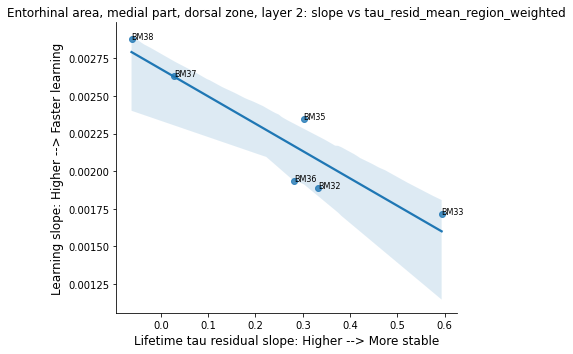

In [ ]:
example_row = corr_tau_resid_name.sort_values('p_value').iloc[4]
f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Learning slope: Higher --> Faster learning', fontsize=12);
ax.set_xlabel('Lifetime tau residual slope: Higher --> More stable', fontsize=12);

,ANM,tau_resid_mean_region_weighted,time_to_criterion_trial
0,BM32,-0.366935,606.0
1,BM33,-0.552949,886.0
2,BM35,-0.591063,501.0
3,BM36,0.111157,1209.0
4,BM37,-0.286650,1045.0
5,BM38,-0.620689,498.0


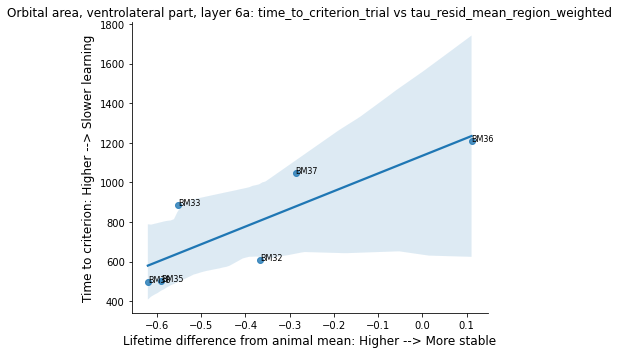

In [185]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, ventrolateral part, layer 6a'].iloc[4]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

In [ ]:
corr_tau_resid_name.sort_values('p_value').head(10)

,metric,region,n,slope,intercept,r_value,p_value,region_col,value_col,residual,measure_label,region_N_sum,neg_log10_p,coarse
3041,within_day_gain_sum,"Gustatory areas, layer 6a",6,-198.959432,4.711295,-0.995329,0.000033,Name,fraction,True,fraction_resid,501870.0,4.485733,Isocortex
969,intercept,"Primary motor area, Layer 6a",6,229.204071,2.779995,0.972706,0.001107,Name,fraction,True,fraction_resid,3526031.0,2.955729,Isocortex
220,slope,"Laterointermediate area, layer 6a",6,-0.054713,0.001601,-0.958953,0.002493,Name,fraction,True,fraction_resid,111601.0,2.603324,Isocortex
1204,mean_accuracy,"Anterolateral visual area, layer 6b",6,10.688174,0.664999,0.958139,0.002592,Name,fraction,True,fraction_resid,23823.0,2.586391,Isocortex
128,slope,"Entorhinal area, medial part, dorsal zone, lay...",6,-0.031630,0.002922,-0.957077,0.002724,Name,fraction,True,fraction_resid,1774780.0,2.564791,Hippocampal formation
1781,mean_dprime,"Anterolateral visual area, layer 6b",6,71.728809,1.124282,0.953915,0.003137,Name,fraction,True,fraction_resid,23823.0,2.503514,Isocortex
2598,time_to_criterion_trial,"Orbital area, lateral part, layer 5",6,22900.091459,628.952162,0.941677,0.005003,Name,fraction,True,fraction_resid,1270859.0,2.300751,Isocortex
21,slope,"Agranular insular area, ventral part, layer 6b",6,-0.026656,0.001449,-0.940204,0.005256,Name,fraction,True,fraction_resid,3294.0,2.279305,Isocortex
89,slope,Cuneate nucleus,4,0.015910,0.003638,0.994161,0.005839,Name,fraction,True,fraction_resid,114706.0,2.233673,Medulla
3226,within_day_gain_sum,Piriform area,6,-133.430305,6.642187,-0.932568,0.006667,Name,fraction,True,fraction_resid,13641190.0,2.176047,Olfactory areas


In [26]:
# Choose region of interest
roi = example_row.region  # e.g., "Hippocampus field CA1"

# Per-animal mean tau (all regions)
tau_mean_per_animal = combined_filtered.groupby("ANM")["tau"].mean().rename("tau_mean_animal")

# Rows for this region
region_rows = combined_filtered[combined_filtered["Name"] == roi].copy()
region_rows = region_rows.merge(tau_mean_per_animal, on="ANM", how="left")
region_rows["tau_resid"] = region_rows["tau"] - region_rows["tau_mean_animal"]

# Show raw and residual tau values
display(region_rows[["ANM", "Name", "tau", "tau_mean_animal", "tau_resid", "N"]].head(30))

# Weighted per-animal summaries for this region
def weighted_mean(arr, weights):
    import numpy as np
    m = np.isfinite(arr) & np.isfinite(weights) & (weights > 0)
    return (arr[m] * weights[m]).sum() / weights[m].sum() if m.any() else float("nan")

summaries = []
for ani, sub in region_rows.groupby("ANM"):
    w = sub["N"].to_numpy()
    summaries.append({
        "ANM": ani,
        "tau_mean_weighted": weighted_mean(sub["tau"].to_numpy(), w),
        "tau_resid_weighted": weighted_mean(sub["tau_resid"].to_numpy(), w),
        "N_sum": sub["N"].sum(),
    })
import pandas as pd
summary_df = pd.DataFrame(summaries)
# After building summary_df as above
beh_cols = ["ANM", "slope", "intercept", "mean_accuracy", "mean_dprime",
            "time_to_criterion_trial", "within_day_gain_sum"]
summary_with_beh = summary_df.merge(behavior[beh_cols], on="ANM", how="left")
display(summary_with_beh)



,ANM,Name,tau,tau_mean_animal,tau_resid,N
0,BM32,"Entorhinal area, medial part, dorsal zone, lay...",3.515783,4.188321,-0.672538,26819.0
1,BM32,"Entorhinal area, medial part, dorsal zone, lay...",4.596452,4.188321,0.408131,106076.0
2,BM32,"Entorhinal area, medial part, dorsal zone, lay...",4.651608,4.188321,0.463287,143142.0
3,BM33,"Entorhinal area, medial part, dorsal zone, lay...",5.967096,6.376184,-0.409088,46258.0
4,BM33,"Entorhinal area, medial part, dorsal zone, lay...",7.117453,6.376184,0.741270,313443.0
5,BM34,"Entorhinal area, medial part, dorsal zone, lay...",5.928704,6.556460,-0.627756,26718.0
6,BM34,"Entorhinal area, medial part, dorsal zone, lay...",6.931296,6.556460,0.374836,188361.0
7,BM34,"Entorhinal area, medial part, dorsal zone, lay...",7.384014,6.556460,0.827554,148462.0
8,BM37,"Entorhinal area, medial part, dorsal zone, lay...",5.603004,6.216883,-0.613879,27235.0
9,BM37,"Entorhinal area, medial part, dorsal zone, lay...",6.053828,6.216883,-0.163055,28855.0


,ANM,tau_mean_weighted,tau_resid_weighted,N_sum,slope,intercept,mean_accuracy,mean_dprime,time_to_criterion_trial,within_day_gain_sum
0,BM32,4.520059,0.331738,276037.0,0.001890,0.019690,0.662316,1.118724,606.0,9.045877
1,BM33,6.969516,0.593332,359701.0,0.001714,-0.739395,0.547481,0.326817,886.0,8.478892
2,BM34,7.042492,0.486032,363541.0,NaN,NaN,NaN,NaN,NaN,NaN
3,BM35,6.344652,0.301726,266453.0,0.002345,-0.213941,0.671221,1.144012,501.0,8.738465
4,BM36,6.004744,0.281376,189755.0,0.001934,-1.434306,0.594896,0.659529,1209.0,9.849362
5,BM37,6.244997,0.028114,117942.0,0.002629,-1.423463,0.524561,0.181751,1045.0,8.977398
6,BM38,6.848433,-0.061894,201351.0,0.002879,-0.466209,0.674256,1.199128,498.0,11.826728


WED

Precomputing per-animal global tau pools...


  0%|          | 0/7 [00:00<?, ?it/s]

{'BM32': 3.6307430890958776,
 'BM33': 5.210674893885986,
 'BM34': 5.372494075695852,
 'BM35': 5.019091919204382,
 'BM36': 4.8337884728093705,
 'BM37': 5.137103470410019,
 'BM38': 5.721067544303515}

In [ ]:
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import ast
from scipy.stats import linregress
import multiprocessing as mp


np.random.seed(0)
region_col = "Name"
n_boot = 5000          # adjust for speed/precision
sample_size = 30_000  # draws per animal-region AND per animal-global
min_animals = 6
min_region_pixels = 100_000
n_jobs = mp.cpu_count()-4  # or set to a number to limit cores

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# Precompute per-animal all-region tau pools
animal_all_tau = {}
print("Precomputing per-animal global tau pools...")
for ani, sub in tqdm(combined_filtered.groupby("ANM"), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_all_tau[ani] = vals

# Precompute per animal-region arrays
region_animal_arrays = {}
print("Precomputing per-animal-region tau pools...")
for (reg, ani), sub in tqdm(combined_filtered.groupby([region_col, "ANM"]), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size and ani in animal_all_tau:
        region_animal_arrays.setdefault(reg, {})[ani] = vals

# Filter regions by pixel count
region_pixels = combined_filtered.groupby(region_col)["N"].sum().to_dict()
filtered_items = [
    (reg, animal_map)
    for reg, animal_map in region_animal_arrays.items()
    if region_pixels.get(reg, 0) >= min_region_pixels
]
print(f"Keeping {len(filtered_items)} regions (>= {min_region_pixels} pixels) out of {len(region_animal_arrays)}")

def bootstrap_region(args):
    reg, animal_map = args
    records = []
    boot_means = []
    for ani, vals in animal_map.items():
        glob = animal_all_tau.get(ani)
        if vals.size == 0 or glob is None or glob.size == 0:
            continue
        # vectorized bootstrap for this animal
        reg_idx = np.random.randint(0, vals.size, size=(n_boot, sample_size))
        glob_idx = np.random.randint(0, glob.size, size=(n_boot, sample_size))
        reg_means = vals[reg_idx].mean(axis=1)
        glob_means = glob[glob_idx].mean(axis=1)
        centered = reg_means - glob_means
        boot_means.append(pd.DataFrame({
            "boot": np.arange(n_boot),
            "ANM": ani,
            "tau_boot_mean_centered": centered,
        }))
    if not boot_means:
        return pd.DataFrame()
    boot_df = pd.concat(boot_means, ignore_index=True)
    for metric in metrics_to_use:
        beh_sub = behavior[["ANM", metric]].dropna()
        merged = boot_df.merge(beh_sub, on="ANM")
        if merged.empty:
            continue
        for b, sub_b in merged.groupby("boot"):
            if sub_b["ANM"].nunique() < min_animals:
                continue
            lr = linregress(sub_b["tau_boot_mean_centered"], sub_b[metric])
            records.append({
                "boot": b,
                "region": reg,
                "metric": metric,
                "slope": lr.slope,
                "p_value": lr.pvalue,
                "n_animals": sub_b["ANM"].nunique(),
            })
    return pd.DataFrame(records)

print("Running parallel bootstraps...")
with mp.Pool(n_jobs) as pool:
    results = list(tqdm(pool.imap(bootstrap_region, filtered_items),
                        total=len(filtered_items), desc="Regions"))

boot_corr = pd.concat([r for r in results if not r.empty], ignore_index=True)

summary_list = []
for (reg, metric), sub in boot_corr.groupby(['region','metric']):
    slopes = sub['slope']
    summary_list.append({
        'region': reg,
        'metric': metric,
        'slope_mean': slopes.mean(),
        'slope_std': slopes.std(ddof=1),
        'sign_frac_pos': (slopes > 0).mean(),
        'frac_sig_p05': (sub['p_value'] < 0.05).mean(),
        'n_boot': len(sub),
        'n_animals_min': sub['n_animals'].min(),
        'region_N_sum': region_pixels.get(reg, np.nan),
    })
boot_summary = pd.DataFrame(summary_list)


Precomputing per-animal global tau pools...


  0%|          | 0/7 [00:00<?, ?it/s]

Precomputing per-animal-region tau pools...


  0%|          | 0/3931 [00:00<?, ?it/s]

Keeping 444 regions (>= 100000 pixels) out of 581
Running parallel bootstraps...


Regions:   0%|          | 0/444 [00:00<?, ?it/s]

Process ForkPoolWorker-2248:
Process ForkPoolWorker-2283:
Process ForkPoolWorker-2205:
Process ForkPoolWorker-2173:
Process ForkPoolWorker-2289:
Process ForkPoolWorker-2170:
Process ForkPoolWorker-2246:
Process ForkPoolWorker-2213:
Process ForkPoolWorker-2171:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process ForkPoolWorker-2162:
Traceback (most recent call last):
  File "/groups/spruston/home/moharb/mambaforge/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/groups/spruston/home/moharb/mambaforge/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/groups/spruston/home/moharb/mambaforge/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/groups/spruston/home/moharb/mambaforge/lib/python3.9/multiprocessing/process.py", line 315, in _boots

KeyboardInterrupt: 

In [191]:
import multiprocessing as mp
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import ast
from scipy.stats import linregress

np.random.seed(0)
region_col = "Name"
n_boot = 3000
sample_size = 30_000
batch = 100
min_animals = 5
metrics_to_use = metrics  # or set explicitly
n_jobs = mp.cpu_count()-4

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# 1) Precompute global tau mean per animal
animal_global_mean = {}
for ani, sub in combined_filtered.groupby("ANM"):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_global_mean[ani] = np.median(vals)
missing_animals = set(combined_filtered["ANM"].unique()) - set(animal_global_mean)
if missing_animals:
    raise ValueError(f"Missing global tau mean for animals: {sorted(missing_animals)}")

# 2) Per animal–region pools
region_animal_arrays = {}
for (reg, ani), sub in combined_filtered.groupby([region_col, "ANM"]):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        region_animal_arrays.setdefault(reg, {})[ani] = vals

def bootstrap_region(args):
    reg, animal_map = args
    rows = []
    for ani, vals in animal_map.items():
        gmean = animal_global_mean[ani]  # will KeyError if missing
        n_eff = min(sample_size, vals.size)
        for start in range(0, n_boot, batch):
            k = min(batch, n_boot - start)
            idx = np.random.randint(0, vals.size, size=(k, n_eff))
            reg_means = vals[idx].mean(axis=1)
            centered = reg_means - gmean
            rows.append(pd.DataFrame({
                "boot": np.arange(start, start + k),
                "ANM": ani,
                "tau_boot_mean_centered": centered,
            }))
    boot_df = pd.concat(rows, ignore_index=True)
    records = []
    for metric in metrics_to_use:
        beh_sub = behavior[["ANM", metric]].dropna()
        merged = boot_df.merge(beh_sub, on="ANM")
        for b, sub_b in merged.groupby("boot"):
            if sub_b["ANM"].nunique() < min_animals:
                continue
            lr = linregress(sub_b["tau_boot_mean_centered"], sub_b[metric])
            records.append({
                "boot": b,
                "region": reg,
                "metric": metric,
                "slope": lr.slope,
                "p_value": lr.pvalue,
                "n_animals": sub_b["ANM"].nunique(),
            })
    return pd.DataFrame(records)

with mp.Pool(n_jobs) as pool:
    results = list(tqdm(pool.imap(bootstrap_region, region_animal_arrays.items()),
                        total=len(region_animal_arrays), desc="Regions"))
boot_corr = pd.concat(results, ignore_index=True)


Regions:   0%|          | 0/581 [00:00<?, ?it/s]

In [153]:
animal_global_mean


{'BM32': 3.6307430890958776,
 'BM33': 5.210674893885986,
 'BM34': 5.372494075695852,
 'BM35': 5.019091919204382,
 'BM36': 4.8337884728093705,
 'BM37': 5.137103470410019,
 'BM38': 5.721067544303515}

In [192]:
from datetime import datetime
out_dir = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning")
out_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

boot_corr_path = out_dir / f"boot_corr_tau_resid_{ts}.csv"
boot_summary_path = out_dir / f"boot_summary_tau_resid_{ts}.csv"

boot_corr.to_csv(boot_corr_path, index=False)
boot_summary.to_csv(boot_summary_path, index=False)

print(f"Saved boot_corr to {boot_corr_path}")
print(f"Saved boot_summary to {boot_summary_path}")

Saved boot_corr to /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_corr_tau_resid_20251210_153748.csv
Saved boot_summary to /groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning/boot_summary_tau_resid_20251210_153748.csv


In [ ]:
from pathlib import Path
import pandas as pd

out_dir = Path("/groups/spruston/home/moharb/DELTA_Behavior/outputs/dprime_learning")
corr_files = sorted(out_dir.glob("boot_corr_tau_resid_*.csv"))
summary_files = sorted(out_dir.glob("boot_summary_tau_resid_*.csv"))
if not corr_files or not summary_files:
    raise FileNotFoundError("No saved boot_corr/boot_summary files found.")

boot_corr = pd.read_csv(corr_files[-1])
boot_summary = pd.read_csv(summary_files[-1])

print(f"Loaded {corr_files[-1]}")
print(f"Loaded {summary_files[-1]}")
boot_summary.head()


In [193]:

# Rank per metric: high mean slope and consistent sign
ranked = {}
metrics_to_use = [
    "slope",
    "intercept",
    "mean_accuracy",
    "mean_dprime",
    "time_to_criterion_trial",
    "within_day_gain_sum",
]
# Map region -> original pixel count (sum of N across that region)
region_pixels = combined_filtered.groupby("Name")["N"].sum().to_dict()

# Add to boot_summary
# Add absolute slope stats
boot_summary["slope_abs_mean"] = boot_summary["slope_mean"].abs()
boot_summary["slope_abs_std"] = boot_summary["slope_std"]  # std of signed slopes; add another pass if you need std of abs
# Include region size if not already
region_pixels = combined_filtered.groupby("Name")["N"].sum().to_dict()
boot_summary["region_N_sum"] = boot_summary["region"].map(region_pixels)

# Rebuild ranked dict using absolute slope
ranked = {}
for metric in metrics_to_use:
    dfm = boot_summary[
        (boot_summary["metric"] == metric) &
        (boot_summary["n_animals_min"] >= min_animals) &
        (boot_summary["frac_sig_p05"] > 0.8)
    ].copy()
    dfm = dfm.sort_values("slope_mean", ascending=False)  # or slope_abs_mean if you prefer
    ranked[metric] = dfm.head(100)

for metric, dfm in ranked.items():
    print(f"\nTop regions for metric: {metric} (frac_sig_p05 > 0.8)\n")
    display(dfm[[
        "region", "slope_mean", "slope_std", "sign_frac_pos",
        "frac_sig_p05", "n_boot", "n_animals_min", "region_N_sum"
    ]])



Top regions for metric: slope (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
15,"Accessory olfactory bulb, mitral layer",-0.000936,0.000011,0.0,1.000,1000,6,313015.0
1485,Posterior amygdalar nucleus,-0.001429,0.000026,0.0,1.000,1000,6,1231883.0
375,Claustrum,-0.002027,0.000054,0.0,0.805,1000,6,617847.0
615,"Entorhinal area, medial part, dorsal zone, lay...",-0.003786,0.000195,0.0,1.000,1000,6,1120546.0
975,"Laterointermediate area, layer 6a",-0.006567,0.000448,0.0,1.000,1000,6,111601.0



Top regions for metric: intercept (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
798,"Infralimbic area, layer 2/3",-0.915345,0.005686,0.0,1.0,1000,6,175654.0
1278,"Orbital area, ventrolateral part, layer 5",-1.306238,0.012583,0.0,1.0,1000,6,640477.0
1284,"Orbital area, ventrolateral part, layer 6a",-2.463413,0.051238,0.0,1.0,1000,6,253998.0
1230,"Orbital area, lateral part, layer 5",-2.744704,0.059110,0.0,1.0,1000,6,1270859.0



Top regions for metric: mean_accuracy (frac_sig_p05 > 0.8)



...

,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
2,"Accessory olfactory bulb, glomerular layer",-0.584469,0.005890,0.0,0.999,1000,6,104909.0
620,"Entorhinal area, medial part, dorsal zone, lay...",-1.722778,0.040263,0.0,1.000,1000,6,1124186.0
1232,"Orbital area, lateral part, layer 5",-1.890624,0.036200,0.0,1.000,1000,6,1270859.0



Top regions for metric: time_to_criterion_trial (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
1264,"Orbital area, medial part, layer 6a",1296.455471,30.979000,1.0,1.000,1000,6,210502.0
1288,"Orbital area, ventrolateral part, layer 6a",1234.222889,23.599304,1.0,1.000,1000,6,253998.0
622,"Entorhinal area, medial part, dorsal zone, lay...",1127.913946,29.670983,1.0,0.999,1000,6,1124186.0



Top regions for metric: within_day_gain_sum (frac_sig_p05 > 0.8)



,region,slope_mean,slope_std,sign_frac_pos,frac_sig_p05,n_boot,n_animals_min,region_N_sum
755,Hippocampo-amygdalar transition area,-3.317497,0.064721,0.0,0.997,1000,6,542422.0
2339,"Taenia tecta, ventral part",-3.799198,0.073367,0.0,1.000,1000,6,866408.0
377,Claustrum,-5.964286,0.132994,0.0,1.000,1000,6,617847.0
563,"Endopiriform nucleus, dorsal part",-6.372879,0.178057,0.0,0.867,1000,6,2188513.0
311,"Basomedial amygdalar nucleus, anterior part",-7.108754,0.182771,0.0,1.000,1000,6,900468.0
1445,Piriform area,-7.866033,0.305370,0.0,1.000,1000,6,13641190.0
2435,"Ventral auditory area, layer 6a",-9.609382,0.404880,0.0,0.995,1000,6,325173.0
743,"Gustatory areas, layer 6a",-11.202792,0.447886,0.0,1.000,1000,6,501870.0


  0%|          | 0/15 [00:00<?, ?it/s]

Saved 15 fraction images to ../outputs/fraction_pulse_whole_slide


In [189]:
animal_all_tau = {}
print("Precomputing per-animal global tau pools...")
for ani, sub in tqdm(combined_filtered.groupby("ANM"), leave=False):
    vals = np.concatenate([to_array(v) for v in sub["tau_values"] if to_array(v).size])
    if vals.size:
        animal_all_tau[ani] = vals
animal_global_mean = {ani: np.median(vals) for ani, vals in animal_all_tau.items()}


Precomputing per-animal global tau pools...


  0%|          | 0/7 [00:00<?, ?it/s]

In [190]:
animal_global_mean


{'BM32': 3.632351875305176,
 'BM33': 4.979085445404053,
 'BM34': 5.10575532913208,
 'BM35': 4.835780620574951,
 'BM36': 4.5970988273620605,
 'BM37': 4.920000076293945,
 'BM38': 5.4297776222229}

In [195]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import tifffile as tiff

out_dir = Path("../outputs/fraction_pulse_whole_slide")
out_dir.mkdir(parents=True, exist_ok=True)

# Target ROI name
TARGET_NAME = "Orbital area, lateral part, layer 5"
roi = TARGET_NAME
roi_df = combined_filtered[combined_filtered["Name"] == roi].copy()

# Round → base path
base_map = {
    12: Path("/nearline/spruston/Boaz/DELTA/GluA2_Round12"),
    13: Path("/nearline/spruston/Boaz/DELTA/GluA2_Round13"),
}

# Preload label table
label_df = pd.read_csv(
    Path("../labels.txt"),
    sep=r"\s+",
    comment="#",
    header=None,
    names=["ID", "R", "G", "B", "A", "VIS", "MSH", "LABEL"],
)
label_df["LABEL"] = label_df["LABEL"].str.strip('"')
label_df["hex"] = label_df.apply(lambda r: f"{int(r.R):02X}{int(r.G):02X}{int(r.B):02X}", axis=1)
hex_to_id   = dict(zip(label_df["hex"], label_df["ID"]))

def decode_nl_png(nl_path: Path):
    png = np.array(Image.open(nl_path).convert("RGB"), dtype=np.uint8)
    h, w, _ = png.shape
    flat = png.reshape(-1, 3)
    hex_vals = np.array([f"{r:02X}{g:02X}{b:02X}" for r, g, b in flat])
    ids = np.array([hex_to_id.get(hx, 0) for hx in hex_vals], dtype=np.int64).reshape(h, w)
    return ids

target_ids = label_df.loc[label_df["LABEL"].str.lower() == TARGET_NAME.lower(), "ID"].unique()
if len(target_ids) == 0:
    raise ValueError(f"Region name not found: {TARGET_NAME}")

saved = []
missing = []
for _ , row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((row["ANM"], "no base_dir", row.get("File", "")))
        continue
    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((row["ANM"], cy5_path, cy3_path))
        continue
    mean = animal_global_mean[row["ANM"]]
    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()
    pulse = arr[2, :, :] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1, :, :] if arr.ndim == 3 else arr

    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    tau = -4./np.log(frac + 1e-6)  # avoid log(0)
    # out_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_tau.tif"
    # tiff.imwrite(out_path, tau, imagej=True)
    # saved.append(out_path)

    # Decode atlas PNG and build mask
    nl_path = base_dir / (Path(row["File"]).stem.replace("_CY5", "") + "_nl.png")
    if nl_path.exists():
        ids = decode_nl_png(nl_path)
        mask = np.isin(ids, target_ids)
        # save overlay for quick viewing
        plt.figure(figsize=(8, 8))
        plt.imshow(tau, cmap="viridis", vmin=2, vmax=10)
        plt.colorbar()
        mask_img = Image.fromarray(mask.astype(np.uint8)*255)
        mask_resized = np.array(mask_img.resize((frac.shape[1], frac.shape[0]), resample=Image.NEAREST)) > 0
        plt.contour(mask_resized, colors="red", linewidths=1)
        plt.axis("off")
        plt.title(f"{row['ANM']} {TARGET_NAME}")
        overlay_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_overlay.png"
        
        plt.tight_layout()
        plt.savefig(overlay_path, dpi=200)
        plt.close()

print(f"Saved {len(saved)} fraction images to {out_dir}")
if missing:
    print("Missing pairs (ANM, CY5, CY3):")
    for m in missing[:10]:
        print(m)


  0%|          | 0/23 [00:00<?, ?it/s]

Saved 0 fraction images to ../outputs/fraction_pulse_whole_slide


In [196]:
import math
import matplotlib.pyplot as plt

# Collect per-animal panels
panels = []
missing = []

for _, row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    ani = row["ANM"]
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((ani, "no base_dir", row.get("File", "")))
        continue

    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((ani, cy5_path, cy3_path))
        continue

    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()
    pulse = arr[2, :, :] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1, :, :] if arr.ndim == 3 else arr

    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    tau = -4.0 / np.log(frac + 1e-6)  # days
    tau = tau - animal_global_mean.get(ani)
    print(f"Animal {ani}: global mean tau = {animal_global_mean.get(ani):.3f} days")
    nl_path = base_dir / (Path(row["File"]).stem.replace("_CY5", "") + "_nl.png")
    if not nl_path.exists():
        missing.append((ani, "missing nl", nl_path))
        continue

    ids = decode_nl_png(nl_path)
    mask = np.isin(ids, target_ids)
    mask_resized = np.array(
        Image.fromarray(mask.astype(np.uint8) * 255)
        .resize((frac.shape[1], frac.shape[0]), resample=Image.NEAREST)
    ) > 0

    panels.append((ani, tau, mask_resized))



  0%|          | 0/23 [00:00<?, ?it/s]

Animal BM32: global mean tau = 3.632 days
Animal BM32: global mean tau = 3.632 days
Animal BM32: global mean tau = 3.632 days
Animal BM33: global mean tau = 4.979 days
Animal BM33: global mean tau = 4.979 days
Animal BM33: global mean tau = 4.979 days
Animal BM34: global mean tau = 5.106 days
Animal BM34: global mean tau = 5.106 days
Animal BM34: global mean tau = 5.106 days
Animal BM37: global mean tau = 4.920 days
Animal BM37: global mean tau = 4.920 days
Animal BM37: global mean tau = 4.920 days
Animal BM37: global mean tau = 4.920 days
Animal BM35: global mean tau = 4.836 days
Animal BM35: global mean tau = 4.836 days
Animal BM35: global mean tau = 4.836 days
Animal BM35: global mean tau = 4.836 days
Animal BM38: global mean tau = 5.430 days
Animal BM38: global mean tau = 5.430 days
Animal BM38: global mean tau = 5.430 days
Animal BM36: global mean tau = 4.597 days
Animal BM36: global mean tau = 4.597 days
Animal BM36: global mean tau = 4.597 days


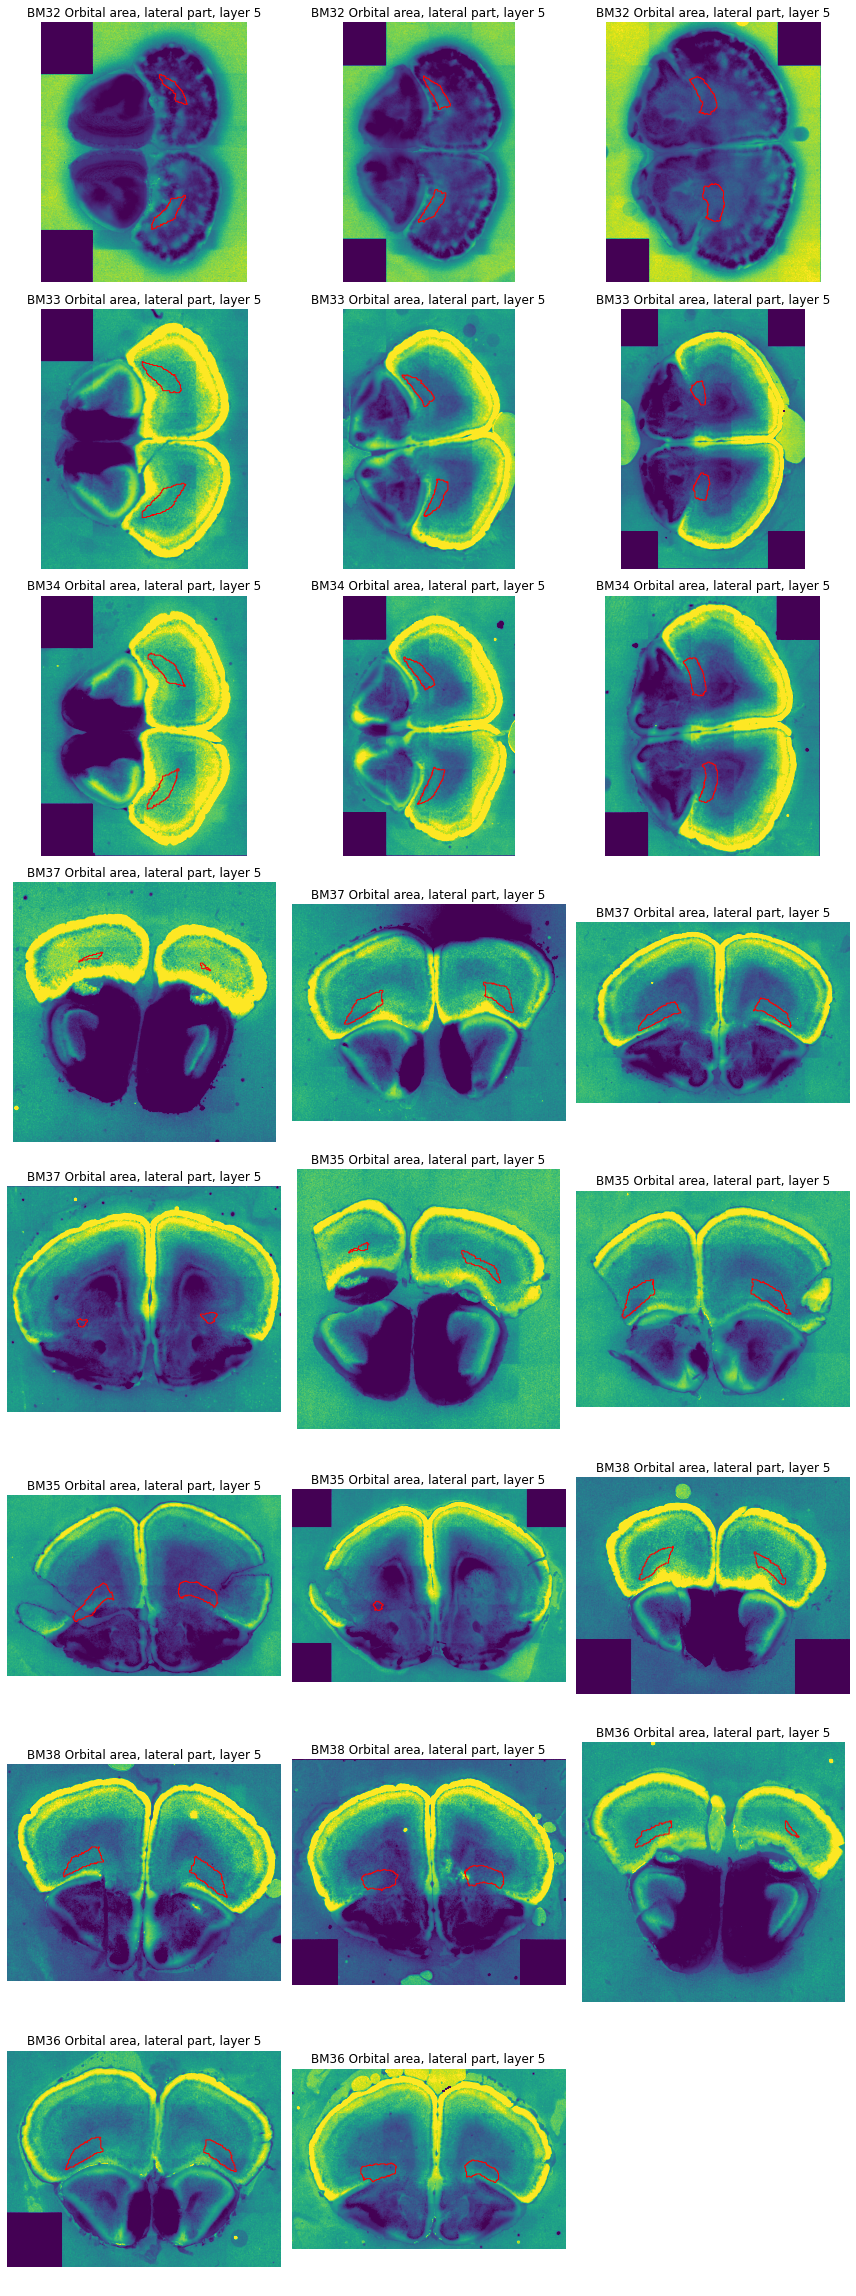

In [206]:
# Plot subplots
n = len(panels)
if n:
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (ani, tau_img, mask_img) in zip(axes, panels):
        im = ax.imshow(tau_img, cmap="viridis", vmin=-1, vmax=3)
        ax.contour(mask_img, colors="red", linewidths=1)
        ax.set_title(f"{ani} {TARGET_NAME}")
        ax.axis("off")
    for ax in axes[len(panels):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

if missing:
    print("Missing items (showing up to 10):")
    for m in missing[:10]:
        print(m)


,ANM,tau_resid_mean_region_weighted,mean_accuracy
0,BM32,-0.068519,0.662316
1,BM33,0.149222,0.547481
2,BM35,-0.282751,0.671221
3,BM36,0.215463,0.594896
4,BM37,0.192692,0.524561
5,BM38,-0.110272,0.674256


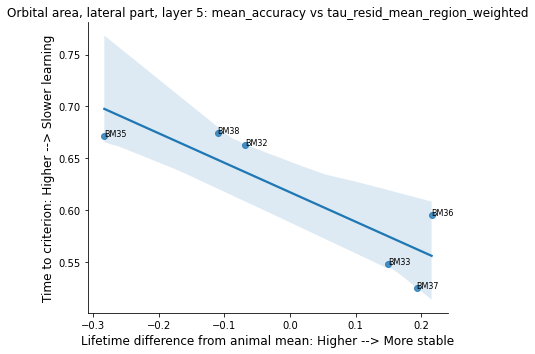

In [203]:
# find row by name from corr_tau_resid_name
example_row = corr_tau_resid_name[corr_tau_resid_name['region'] == 'Orbital area, lateral part, layer 5'].iloc[2]

f = plot_corr_example(example_row, region_tau_resid, behavior)
ax = f.gca()
ax.set_ylabel('Time to criterion: Higher --> Slower learning', fontsize=12);
ax.set_xlabel('Lifetime difference from animal mean: Higher --> More stable', fontsize=12);

In [124]:
pulse.shape

(3, 2248, 1484)

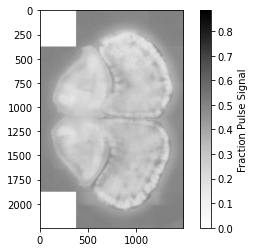

In [137]:
plt.imshow(frac, cmap='Greys')
plt.colorbar(label='Fraction Pulse Signal')

In [101]:
import os
os.listdir("/nearline/spruston/Boaz/DELTA/GluA2_Round12/")

['Slide 4 of 1_Region 005.png',
 'Slide 7 of 1_Region 002_nl.flat',
 'Slide 8 of 2_Region 001_nl.flat',
 'Slide 5 of 2_Region 006_nl.flat',
 'Slide 8 of 2_Region 004_CY3.tiff',
 'Slide 8 of 2_Region 003_DAPI.tiff',
 'Slide 8 of 2_Region 002_CY3.tiff',
 'Slide 5 of 2_Region 001_DAPI.tiff',
 'Slide 2 from cassette 1_Region 001_CY5.tiff',
 'Slide 1 from cassette 1_Region 001_Probabilities.tif',
 'Slide 1 from cassette 1_Region 001_CY3.tiff',
 'Slide 1 from cassette 1_Region 006_DAPI.tiff',
 'ds_dapi.m',
 'Slide 1 from cassette 2_Region 003_DAPI.tiff',
 'Slide 4 of 1_Region 003_DAPI.tiff',
 'Slide 5 of 1_Region 002_Probabilities.tif',
 'Slide 5 of 1_Region 004_nl.flat',
 'Slide 8 of 1_Region 001_nl.flat',
 'Slide 2 from cassette 1_Region 001_nl.png',
 'Slide 8 of 1_Region 005_nl.flat',
 'Slide 5 of 1_Region 003_nl.flat',
 'Slide 1 from cassette 2_Region 001_nl.png',
 'Slide 5 of 2_Region 002_CY3.tiff',
 'Slide 8 of 2_Region 003_nl.flat',
 'Slide 2 from cassette 2_Region 003_Probabilities.t

In [99]:
os.listdir("/nearline/spruston/Boaz")

['DELTA', 'Easi_FISH', 'Histology', 'Mesoscope']

,region,ANM,tau_raw_mean,tau_resid_mean,n_pixels_region,tau_animal_global_mean,within_day_gain_sum
0,"Laterointermediate area, layer 6a",BM32,3.621369,-0.009374,11040.0,3.630743,9.045877
1,"Laterointermediate area, layer 6a",BM33,5.225831,0.015156,23538.0,5.210675,8.478892
2,"Laterointermediate area, layer 6a",BM34,5.420564,0.048070,24263.0,5.372494,NaN
3,"Laterointermediate area, layer 6a",BM35,4.981643,-0.037449,13133.0,5.019092,8.738465
4,"Laterointermediate area, layer 6a",BM36,4.844468,0.010680,15983.0,4.833788,9.849362
5,"Laterointermediate area, layer 6a",BM37,5.022182,-0.114922,11063.0,5.137103,8.977398
6,"Laterointermediate area, layer 6a",BM38,5.576173,-0.144894,12581.0,5.721068,11.826728
7,"Gustatory areas, layer 6a",BM32,3.451761,-0.178982,58726.0,3.630743,9.045877
8,"Gustatory areas, layer 6a",BM33,5.084669,-0.126006,101569.0,5.210675,8.478892
9,"Gustatory areas, layer 6a",BM34,5.260273,-0.112221,109252.0,5.372494,NaN


posx and posy should be finite values
posx and posy should be finite values


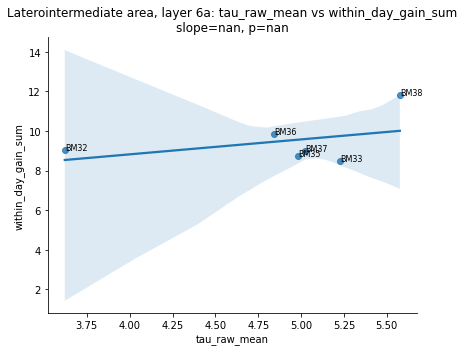

posx and posy should be finite values
posx and posy should be finite values


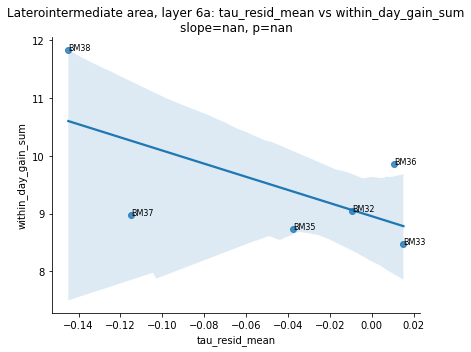

posx and posy should be finite values
posx and posy should be finite values


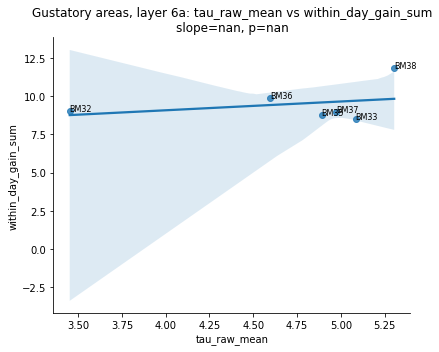

posx and posy should be finite values
posx and posy should be finite values


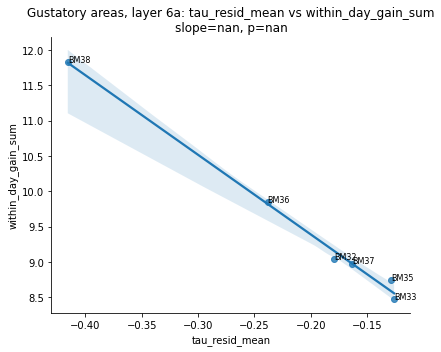

In [56]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

target_regions = [
    "Laterointermediate area, layer 6a",
    "Gustatory areas, layer 6a",
]

def to_array(val):
    if isinstance(val, (list, tuple, np.ndarray)):
        return np.asarray(val, float).ravel()
    if isinstance(val, str):
        try:
            return np.asarray(ast.literal_eval(val), float).ravel()
        except Exception:
            return np.array([], float)
    return np.array([], float)

# Global mean tau per animal (all regions)
animal_tau_mean = (
    combined_filtered.groupby("ANM")["tau_values"]
    .apply(lambda s: np.concatenate([to_array(v) for v in s if to_array(v).size]).mean()
           if any(to_array(v).size for v in s) else np.nan)
    .to_dict()
)

records = []
for reg in target_regions:
    sub = combined_filtered[combined_filtered["Name"] == reg]
    for ani, s in sub.groupby("ANM"):
        vals = np.concatenate([to_array(v) for v in s["tau_values"] if to_array(v).size])
        if vals.size == 0 or ani not in animal_tau_mean:
            continue
        raw_mean = vals.mean()
        resid_mean = raw_mean - animal_tau_mean[ani]
        n_pixels = s["N"].sum()
        records.append({
            "region": reg,
            "ANM": ani,
            "tau_raw_mean": raw_mean,
            "tau_resid_mean": resid_mean,
            "n_pixels_region": n_pixels,
            "tau_animal_global_mean": animal_tau_mean[ani],
        })

df = pd.DataFrame(records)
df = df.merge(behavior[["ANM", "within_day_gain_sum"]], on="ANM", how="left")
display(df)

# Plot raw vs behavior and residual vs behavior
for reg in target_regions:
    dfr = df[df["region"] == reg]
    if dfr.empty:
        print(f"No data for {reg}")
        continue
    for col in ["tau_raw_mean", "tau_resid_mean"]:
        plt.figure(figsize=(6,5))
        sns.regplot(data=dfr, x=col, y="within_day_gain_sum")
        sns.despine(top=True, right=True)
        for _, r in dfr.iterrows():
            plt.text(r[col], r["within_day_gain_sum"], r["ANM"], fontsize=8)
        lr = linregress(dfr[col], dfr["within_day_gain_sum"])
        plt.title(f"{reg}: {col} vs within_day_gain_sum\nslope={lr.slope:.3f}, p={lr.pvalue:.3g}")
        plt.tight_layout()
        plt.show()


In [ ]:

def derive_cy_paths(base_dir: Path, file_name: str):
    stem = Path(file_name).stem
    base_stem = re.sub(r"_CY[0-9]+$", "", stem)  # drop any trailing _CYX
    cy5 = base_dir / f"{base_stem}_CY5.tiff"
    cy3 = base_dir / f"{base_stem}_CY3.tiff"
    # fallback to .tif if .tiff missing
    if not cy5.exists():
        cy5 = base_dir / f"{base_stem}_CY5.tiff"
    if not cy3.exists():
        cy3 = base_dir / f"{base_stem}_CY3.tiff"
    return cy5, cy3

saved, missing = [], []
for _, row in tqdm(roi_df.iterrows(), total=len(roi_df)):
    rnd = int(row.get("Round", 0))
    base_dir = base_map.get(rnd)
    if base_dir is None:
        missing.append((row["ANM"], "no base_dir", row.get("File", "")))
        continue
    cy5_path, cy3_path = derive_cy_paths(base_dir, Path(row["File"]).name)
    if not cy5_path.exists() or not cy3_path.exists():
        missing.append((row["ANM"], cy5_path, cy3_path))
        continue

    with tiff.TiffFile(cy5_path) as tf:
        arr = tf.series[0].asarray()  # or tf.pages[0].asarray()
    pulse = arr[2,:,:] if arr.ndim == 3 else arr

    with tiff.TiffFile(cy3_path) as tf:
        arr = tf.series[0].asarray()
    chase = arr[1,:,:] if arr.ndim == 3 else arr
    denom = pulse + chase
    frac = np.divide(pulse, denom, out=np.zeros_like(pulse, dtype=np.float32), where=denom != 0)
    frac = np.clip(frac, 0, 1)
    out_path = out_dir / f"{row['ANM']}_{cy5_path.stem.replace('_CY5','')}_fraction.tif"
    tiff.imwrite(out_path, frac, imagej=True)
    saved.append(out_path)

print(f"Saved {len(saved)} fraction images to {out_dir}")
if missing:
    print("Missing pairs (ANM, CY5, CY3):")
    for m in missing[:10]:
        print(m)
